In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
# get data ready
df = pd.read_csv("06-study_hours_grades.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [4]:
X = torch.tensor(df["study_hours"].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df["grade"].values, dtype=torch.float32).unsqueeze(1)

In [5]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

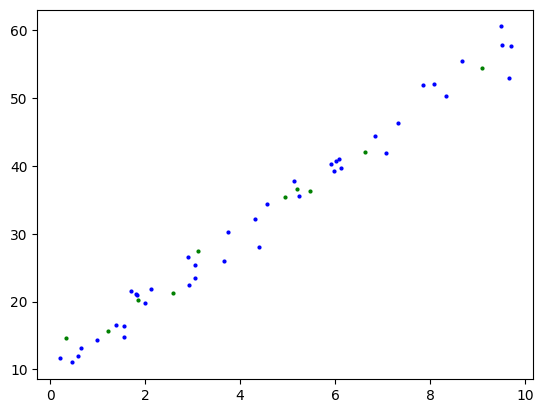

In [6]:
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Test data")
plt.show()

In [7]:
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1) 
    
    def forward(self, x: torch.Tensor) -> torch.Tensor: 
        return self.linear_layer(x)

In [8]:
torch.manual_seed(42)
model = LinearRegressionModel()

In [9]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [10]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [11]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [12]:
epochs = 120

for epoch in range(epochs):
    model.train()
    
    y_pred = model(X_train)
    
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 5 == 0:
        print(f"Epoch : {epoch}, Train Loss : {loss}, Test Loss : {test_loss}")

Epoch : 0, Train Loss : 965.6339721679688, Test Loss : 160.62022399902344
Epoch : 5, Train Loss : 22.257577896118164, Test Loss : 27.251602172851562
Epoch : 10, Train Loss : 21.13695526123047, Test Loss : 25.89261245727539
Epoch : 15, Train Loss : 20.168928146362305, Test Loss : 24.743696212768555
Epoch : 20, Train Loss : 19.254438400268555, Test Loss : 23.6547908782959
Epoch : 25, Train Loss : 18.390506744384766, Test Loss : 22.621475219726562
Epoch : 30, Train Loss : 17.574350357055664, Test Loss : 21.640789031982422
Epoch : 35, Train Loss : 16.803316116333008, Test Loss : 20.709945678710938
Epoch : 40, Train Loss : 16.07491683959961, Test Loss : 19.826316833496094
Epoch : 45, Train Loss : 15.386789321899414, Test Loss : 18.987407684326172
Epoch : 50, Train Loss : 14.736712455749512, Test Loss : 18.190872192382812
Epoch : 55, Train Loss : 14.122581481933594, Test Loss : 17.434463500976562
Epoch : 60, Train Loss : 13.54240608215332, Test Loss : 16.716089248657227
Epoch : 65, Train Los

In [13]:
print(model.state_dict())

OrderedDict({'linear_layer.weight': tensor([[5.6578]]), 'linear_layer.bias': tensor([5.7629])})


In [14]:
model.eval()
with torch.inference_mode():
  y_preds = model(X_test)

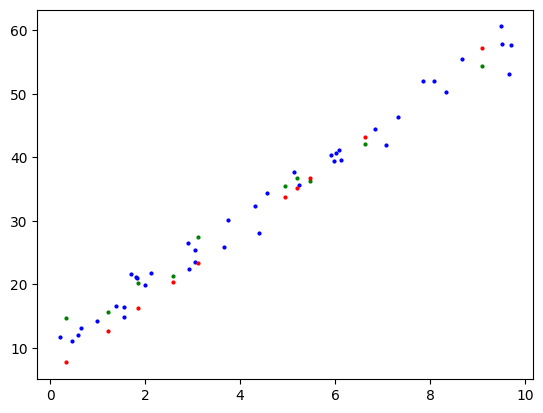

In [15]:
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.scatter(X_test, y_preds, c="r", s=4, label="Predictions")
plt.show()